---
title: CTFs / PSFs Notebook
authors: [gvarnavides]
date: 2026-05-28
---

In [ ]:
import abtem
import numpy as np
import quantem as em
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

plt.rcParams['text.color']='white'
plt.rcParams['xtick.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.labelcolor'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams.update({
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{amsmath}"
# })

abtem.config.set({"dask.lazy":False});


## CTFs / PSFs

In [2]:
symbols = [symbol for symbol in abtem.transfer.polar_symbols if symbol[0] == "C"]
nm = [(int(c[-2]), int(c[-1])) for c in symbols]
dicts = [{symbol: 50**n} for symbol, (n,m) in zip(symbols,nm)]

ctf_objects = [abtem.CTF(semiangle_cutoff=30,energy=100e3,**coefs) for coefs in dicts]
ctfs = [ctf.to_diffraction_patterns(max_angle=30).array for ctf in ctf_objects]
psfs = [ctf.to_point_spread_functions(gpts=256,extent=40).crop(extent=(10,10),offset=(15,15)).array for ctf in ctf_objects]

In [3]:
def array_to_scaled_rgba(array,vmin=0.02,vmax=0.98):
    if np.iscomplexobj(array):
        scaled_amplitude = np.abs(array)
        scaled_angle = np.angle(array)
    else:
        scaled_amplitude = array
        scaled_angle = None

    if scaled_amplitude.std() > 1e-12:
        vmin, vmax = np.quantile(scaled_amplitude,(vmin,vmax))

        scaled_amplitude = (scaled_amplitude.clip(vmin,vmax) - vmin) / (vmax-vmin)
    else:
        scaled_amplitude = np.ones_like(scaled_amplitude)

    rgba = em.visualization.visualization_utils.array_to_rgba(
        scaled_amplitude,
        scaled_angle
    )

    return rgba

def plot_coefficients(nm, arrays):
    nrows, ncols = (5, 7)

    dpi = 72
    fig = plt.figure(figsize=(720/dpi,600/dpi),dpi=dpi)
        
    axes = ImageGrid(
        fig,
        111,
        nrows_ncols=(nrows, ncols),
        **{"axes_pad": 0.0},
    )
    
    axes = np.array(axes).reshape((5, 7))
    
    for array, (n, m) in zip(arrays, nm):
        ax = axes[(n - 1, m)]
        rgba = array_to_scaled_rgba(array,vmin=0,vmax=1)
        ax.imshow(rgba)
    
    for ax in axes.ravel():
        ax.patch.set_alpha(0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
    
    for i, ax in enumerate(axes[:, 0]):
        ax.set_ylabel(f"$n={i + 1}$", fontsize=12)
    
    for i, ax in enumerate(axes[0, :]):
        ax.set_title(f"$m={i}$", fontsize=12)

    fig.patch.set_alpha(0)
        
    return fig

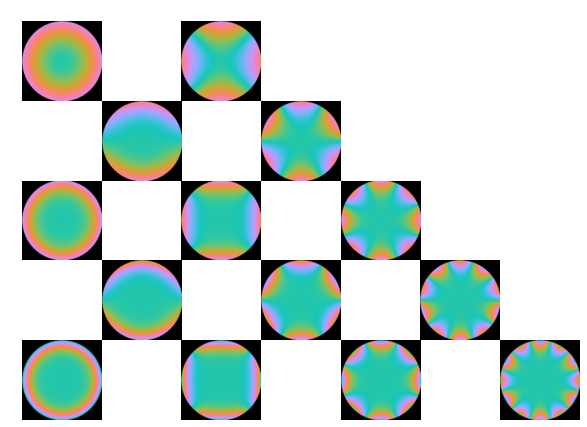

In [7]:
ctfs_fig = plot_coefficients(nm,ctfs)
# ctfs_fig.savefig("../figures/CTFs_table.png",bbox_inches="tight",transparent=True)

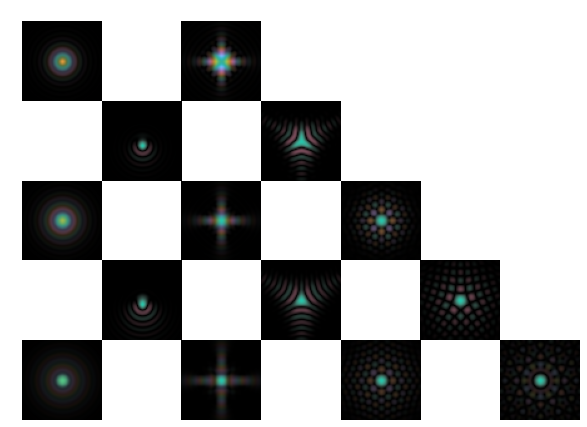

In [6]:
psfs_fig = plot_coefficients(nm,psfs)
# psfs_fig.savefig("../figures/PSFs_table.png",bbox_inches="tight",transparent=True)